#Project Title:Sentiment Analysis of Airline-Related Tweets
#Research Objectives:To identity the airline with the highest volume of negative feedback,analyze the root causes of customer complaints,and propose actionable improvement strategies.
#Target Stakeholders:Airline Customer Experience Teams and Operations Managers,who need to quickly identify the focal points of negative service issues.
#Data sources:Kaggle Dataset:Twitter US Airline Sentiment(Data of Access:April 7,2026)

One.Project Title & Toolkit Import

In [1]:
#Import Toolkit
import pandas as pd
import matplotlib.pyplot as plt
#Global Settings:Consistent chart display and clarity
plt.rcParams['font.sans-serif']=['DejaVu Sans','Heiti TC','Arial Unicode MS']
plt.rcParams['axes.unicode_minus']=False#Fix negative sign display
plt.rcParams['figure.dpi']=100#Unified chart clarity

Two.Data Reading and Basic Verification

In [2]:
#Load Dataset
df=pd.read_csv('Tweets.csv',encoding='utf-8')
#Preview first 5 rows to verity successful data loading
print("="*50)
print("[1.Data Loaded Successfully-First 5 Rows Preview]")
print("="*50)
print(df.head())

[1.Data Loaded Successfully-First 5 Rows Preview]
             tweet_id airline_sentiment  airline_sentiment_confidence  \
0  570306133677760513           neutral                        1.0000   
1  570301130888122368          positive                        0.3486   
2  570301083672813571           neutral                        0.6837   
3  570301031407624196          negative                        1.0000   
4  570300817074462722          negative                        1.0000   

  negativereason  negativereason_confidence         airline  \
0            NaN                        NaN  Virgin America   
1            NaN                     0.0000  Virgin America   
2            NaN                        NaN  Virgin America   
3     Bad Flight                     0.7033  Virgin America   
4     Can't Tell                     1.0000  Virgin America   

  airline_sentiment_gold        name negativereason_gold  retweet_count  \
0                    NaN     cairdin                 NaN 

Three.Basic Dataset Information Exploration

In [3]:
print("\n"+"="*50)
print("[2.Dataset Basic Information]")
print("="*50)
#Data types and non-null value statistics
df.info()
#Descriptive statistics for numerical columns
print("\nNumerical Columns Description:")
print(df.describe())
#Check dataset scale
print(f"\nDataset Overall Scale:{df.shape[0]}Tweets,{df.shape[1]}Features")


[2.Dataset Basic Information]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                

Four.Missing Value Analysis

In [4]:
print("\n"+"="*50)
print("[3.Missing Value Statistics]")
print("="*50)
#Count missing values per column
print("Missing values per column:")
print(df.isnull().sum())
#Calculate missing value percentage(rounded to 2 decimal places)
print("\nMissing Value Percentage per Column:")
print((df.isnull().sum()/
len(df)).round(4)*100)


[3.Missing Value Statistics]
Missing values per column:
tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64

Missing Value Percentage per Column:
tweet_id                         0.00
airline_sentiment                0.00
airline_sentiment_confidence     0.00
negativereason                  37.31
negativereason_confidence       28.13
airline                          0.00
airline_sentiment_gold          99.73
name                             0.00
negativereason_gol

Five.Sentiment Label & Airline Basic Statistics

In [5]:
print("\n"+"="*50)
print("[4.Sentiment Label&Airline Basic Statistics]")
print("="*50)
#Count and percentage of sentiment labels
sentiment_count=df['airline_sentiment'].value_counts()
print("Sentiment Label Distribution:")
print(sentiment_count)
print("\nSentiment Label Percentage:")
print((sentiment_count/
len(df)).round(4)*100)
#Count tweets  per airline
airline_count=df['airline'].value_counts()
print("\nNumber of Tweets per Airline:")
print(airline_count)


[4.Sentiment Label&Airline Basic Statistics]
Sentiment Label Distribution:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

Sentiment Label Percentage:
airline_sentiment
negative    62.69
neutral     21.17
positive    16.14
Name: count, dtype: float64

Number of Tweets per Airline:
airline
United            3822
US Airways        2913
American          2759
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64


Six.Airline and Sentiment Label Cross-Analysis

In [6]:
print("\n"+"="*50)
print("[5.Airline-Sentiment Label Cross Analysis]")
print("="*50)
#Cross-tabulation:Airline and Sentiment Label
airline_sentiment=pd.crosstab(df['airline'],df['airline_sentiment'])
print("Sentiment Analysis by Airline:")
print(airline_sentiment)
#Calculate sentiment percentage per airline(row-wise normalization)
airline_sentiment_pct=pd.crosstab(df['airline'],df['airline_sentiment'],normalize='index').round(4)*100
print("\nSentiment Percentage per Airline(%):")
print(airline_sentiment_pct)


[5.Airline-Sentiment Label Cross Analysis]
Sentiment Analysis by Airline:
airline_sentiment  negative  neutral  positive
airline                                       
American               1960      463       336
Delta                   955      723       544
Southwest              1186      664       570
US Airways             2263      381       269
United                 2633      697       492
Virgin America          181      171       152

Sentiment Percentage per Airline(%):
airline_sentiment  negative  neutral  positive
airline                                       
American              71.04    16.78     12.18
Delta                 42.98    32.54     24.48
Southwest             49.01    27.44     23.55
US Airways            77.69    13.08      9.23
United                68.89    18.24     12.87
Virgin America        35.91    33.93     30.16


Seven.Negative Reason In-Depth Analysis

In [7]:
print("\n"+"="*50)
print("[6.Negative Reason In-Depth Analysis]")
print("="*50)
#Filter negative tweets
negative_df=df[df['airline_sentiment']=='negative']
#Count distribution of negative reasons
neg_reason_count=negative_df['negativereason'].dropna().value_counts()
print("Negative Reason Distribution:")
print(neg_reason_count)
print("\nNegative reason Percentage:")
print((neg_reason_count/
len(negative_df)).round(4)*100)


[6.Negative Reason In-Depth Analysis]
Negative Reason Distribution:
negativereason
Customer Service Issue         2910
Late Flight                    1665
Can't Tell                     1190
Cancelled Flight                847
Lost Luggage                    724
Bad Flight                      580
Flight Booking Problems         529
Flight Attendant Complaints     481
longlines                       178
Damaged Luggage                  74
Name: count, dtype: int64

Negative reason Percentage:
negativereason
Customer Service Issue         31.71
Late Flight                    18.14
Can't Tell                     12.97
Cancelled Flight                9.23
Lost Luggage                    7.89
Bad Flight                      6.32
Flight Booking Problems         5.76
Flight Attendant Complaints     5.24
longlines                       1.94
Damaged Luggage                 0.81
Name: count, dtype: float64


Eight.Data Visualization

8.1 Sentiment distribution Pie Chart


[8.1 Sentiment distribution Pie Chart]


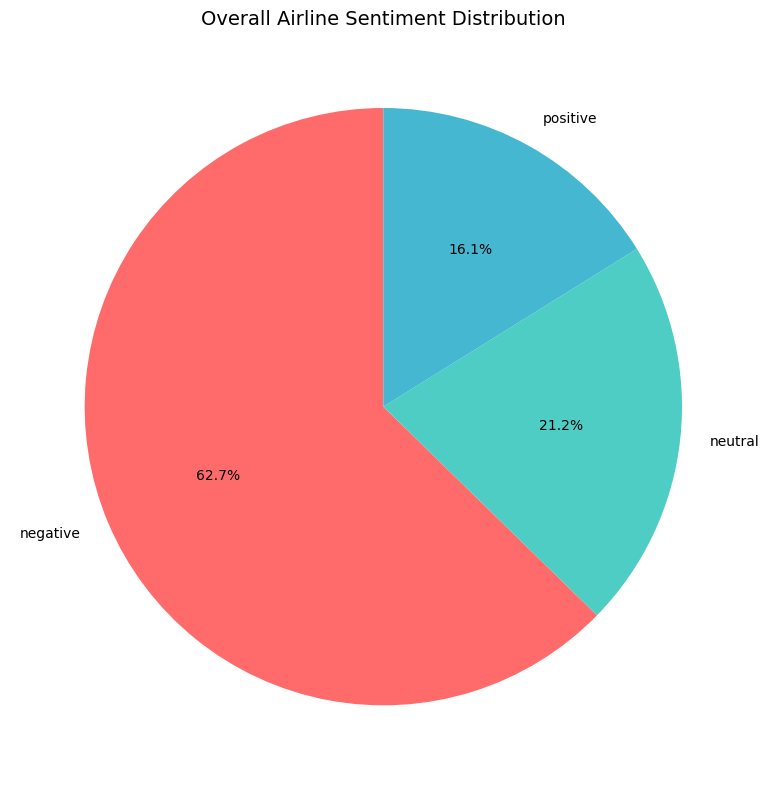

In [8]:
print("\n"+"="*50)
print("[8.1 Sentiment distribution Pie Chart]")
print("="*50)
#Plot sentiment distribution pie chart
plt.figure(figsize=(8,8))
sentiment_count.plot(kind='pie',autopct='%1.1f%%',startangle=90,
                     colors=['#ff6b6b','#4ecdc4','#45b7d1'])
plt.title('Overall Airline Sentiment Distribution',fontsize=14)
plt.ylabel('')#Hide y-axis label
plt.tight_layout()                        
plt.show()

8.2 Stacked Bar Chart


[8.2 Stacked Bar Chart]


<Figure size 1000x600 with 0 Axes>

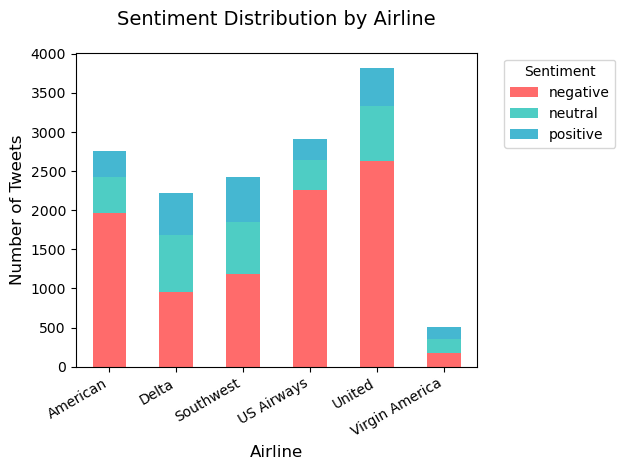

In [9]:
print("\n"+"="*50)
print("[8.2 Stacked Bar Chart]")
print("="*50)
#Plot stacked bar chart
plt.figure(figsize=(10,6))
airline_sentiment.plot(kind='bar',stacked=True,
                       color=['#ff6b6b','#4ecdc4','#45b7d1'])
plt.title('Sentiment Distribution by Airline',fontsize=14,pad=20)
plt.xlabel('Airline',fontsize=12)
plt.ylabel('Number of Tweets',fontsize=12)
plt.legend(title='Sentiment',bbox_to_anchor=(1.05,1),loc='upper left')
plt.xticks(rotation=30,ha='right')
plt.tight_layout()
plt.show()

8.3 Negative Reason Bar Chart


[8.3Negative Reason Bar Chart]


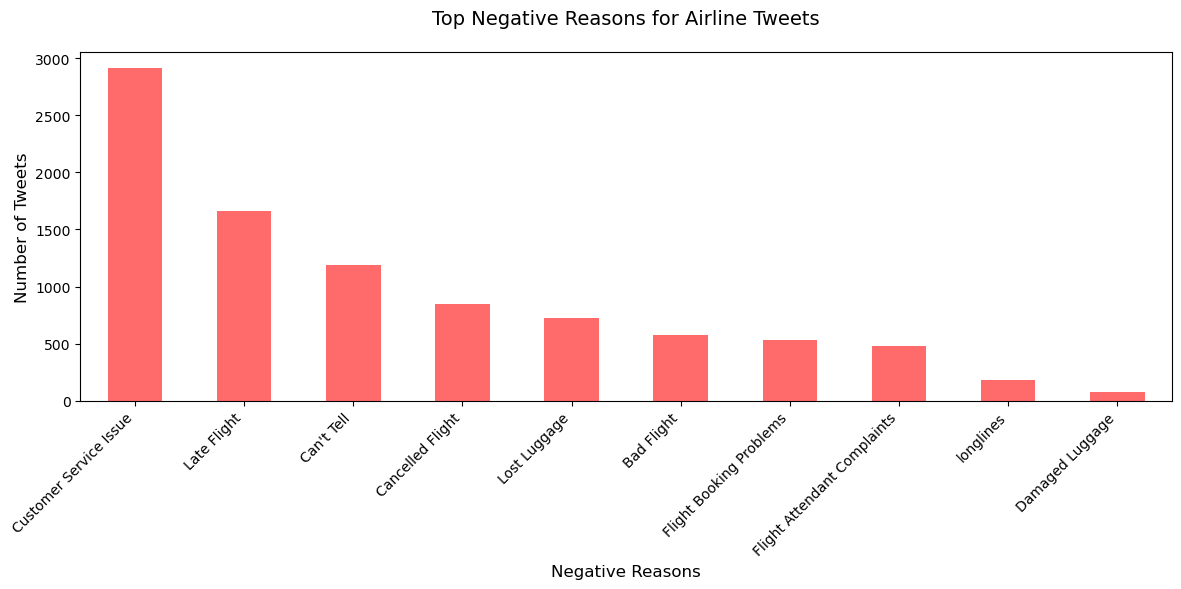

In [10]:
print("\n"+"="*50)
print("[8.3Negative Reason Bar Chart]")
print("="*50)
#Plot negative reason bar chart
plt.figure(figsize=(12,6))
neg_reason_count.plot(kind='bar',color='#ff6b6b')
plt.title('Top Negative Reasons for Airline Tweets',fontsize=14,pad=20)
plt.xlabel('Negative Reasons',fontsize=12)
plt.ylabel('Number of Tweets',fontsize=12)
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

Nine.Sentiment Analysis Conclusions&Recommendations(Based on Twitter Airline Tweet Data)
9.1 Key Findings
#Overall Sentiment:The data-set of 14640 tweets shows a heavily skewed distribution:over 60% negative,about 20% neutral,and less than 15% positive
#Address Key Pain Points:Improve flight on time rates and customer service response processes to reduce complaints.
#Adopt Best Practices:Learn form Virgin America's successful operations to elevate industry service standards.
9.2 Actionable Recommendations
9.2.1 Prioritize Under-performers:Airline like US Airways should audit user experience and fix core issues(e.g. on-time performance,in-flight service).
9.2.2 Address Key Pain Points:Improve flight on-time rates and customer service response processes to reduce complaints.
9.2.3 Adopt Best Practices:Learn from Virgin America's successful operations to elevate industry service standards.
9.3 Conclusion
This analysis identifies critical service pain points and performance gaps in the U.S. airline industry,providing data-driven insights to help airlines improve customer satisfaction and competitiveness.